In [1]:
!pip install -q huggingface_hub transformers torch shap

In [2]:
import shap
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel, AutoTokenizer, ElectraModel, AutoModelForCausalLM, pipeline
from huggingface_hub import hf_hub_download

/Users/irolim/Documents/한중연/4차시/학위논문/플랫폼/KPoEM Interface/shap-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 기초 세팅
REPO_ID = "AKS-DHLAB/KPoEM" # 허깅페이스에 업로드된 감정분류모델 id
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #GPU 사용
THRESH_HOLD = 0.3

In [4]:
# KPoEM_Classifier 클래스
class KPoEM_Classifier(nn.Module):
    def __init__(self, repo_id, device):
        self.labels = [
            '불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경',
            '기대감', '우쭐댐/무시함', '안타까움/실망', '비장함', '의심/불신', '뿌듯함', '편안/쾌적',
            '신기함/관심', '아껴주는', '부끄러움', '공포/무서움', '절망', '한심함', '역겨움/징그러움',
            '짜증', '어이없음', '없음', '패배/자기혐오', '귀찮음', '힘듦/지침', '즐거움/신남', '깨달음',
            '죄책감', '증오/혐오', '흐뭇함(귀여움/예쁨)', '당황/난처', '경악', '부담/안_내킴', '서러움',
            '재미없음', '불쌍함/연민', '놀람', '행복', '불안/걱정', '기쁨', '안심/신뢰'
        ]
        num_labels = len(self.labels)
        #모델 & 토크나이저 로드
        super().__init__()
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(repo_id) 
        self.electra = AutoModel.from_pretrained(repo_id)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.1),
            nn.Linear(self.electra.config.hidden_size, num_labels)
        )

        weights_path = hf_hub_download(repo_id=repo_id, filename="classifier_state.bin") #가중치 불러오기
        self.classifier.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.to(self.device)
        self.eval()

    # 텍스트를 입력받아 최종 logits 반환
    def forward(self, text: str):
        encoding = self.tokenizer(
          text,
          add_special_tokens=True,
          max_length=512,
          padding="max_length",
          truncation=True,
          return_tensors='pt',
        ).to(self.device)

        with torch.no_grad():
            outputs = self.electra(
                input_ids=encoding["input_ids"],
                attention_mask=encoding["attention_mask"],
                token_type_ids=encoding["token_type_ids"]
            )

        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

    def analyze(self, text: str, threshold=0):
        logits = self.forward(text)
        probabilities = torch.sigmoid(logits.squeeze()) #확률로 변환 → threshold 이상이면 선택
        predictions = (probabilities > threshold).int()

        result_dict = {
            self.labels[i]: float(round(probabilities[i].item(), 3))
            for i, label_id in enumerate(predictions)
            if label_id == 1
        }

        # 확률값 기준 내림차순 정렬된 dict로 반환
        result_dict = dict(sorted(result_dict.items(), key=lambda x: x[1], reverse=True))
        return result_dict


In [5]:
# KPoEM 모델 로드
print(f"... '{DEVICE}' 환경에서 '{REPO_ID}' 모델을 로드하고 있습니다 ...")
kpoem_model = KPoEM_Classifier(repo_id=REPO_ID, device=DEVICE)
print("KPoEM 모델을 성공적으로 로드하였습니다.")

... 'cpu' 환경에서 'AKS-DHLAB/KPoEM' 모델을 로드하고 있습니다 ...
KPoEM 모델을 성공적으로 로드하였습니다.


In [6]:
import numpy as np

def shap_predict(texts):
    """
    texts: List[str]
    return: np.ndarray, shape = (len(texts), num_labels)
    """
    kpoem_model.eval()  # 안전장치
    outputs = []

    with torch.no_grad():  # ⭐ 매우 중요
        for text in texts:
            logits = kpoem_model.forward(text)              # (1, num_labels)
            probs = torch.sigmoid(logits)             # (1, num_labels)

            outputs.append(
                probs.squeeze().detach().cpu().numpy()
            )

    return np.vstack(outputs)


In [7]:
import shap

explainer = shap.Explainer(
    shap_predict,
    masker=shap.maskers.Text(kpoem_model.tokenizer)
)


In [8]:
texts = [
    "죽는 날까지 하늘을 우러러",
    "한 점 부끄럼이 없기를,"
]

shap_values = explainer(texts)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
PartitionExplainer explainer: 3it [00:18, 18.93s/it]               


In [9]:
print(shap_values.shape)

(2, 8, 44)


In [10]:
!pip install matplotlib numpy

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [11]:
import matplotlib.pyplot as plt
print("matplotlib OK")

matplotlib OK


In [12]:
idx = kpoem_model.labels.index("부끄러움")
shap.plots.text(shap_values[:, :, idx])

In [23]:
sadness_idx = kpoem_model.labels.index("슬픔")

shap.plots.text(shap_values[:, :, sadness_idx])


In [24]:
THRESH = 0.02

In [25]:
import numpy as np
from collections import defaultdict


In [36]:
import numpy as np
from collections import defaultdict

token_scores = defaultdict(float)

for i in range(len(texts)):  # 두 문장
    shap_vals = shap_values[i, :, sadness_idx].values
    tokens = shap_values[i].data  # 토큰 문자열

    for token, value in zip(tokens, shap_vals):
        if value > 0:  # ⭐ 슬픔을 증가시킨 토큰만
            token_scores[token] += float(value)


In [37]:
token_scores

defaultdict(float,
            {'죽': 0.13092581368982792,
             ' 우': 0.08392013795673847,
             '러': 0.012809352949261665,
             ' 점': 0.05154164880514145,
             ' 부끄럼': 0.0317138209939003,
             '럼': 0.03154546767473221,
             ' 없': 0.03407886065542698,
             '기를': 0.18178585171699524})

In [28]:
!pip install wordcloud

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

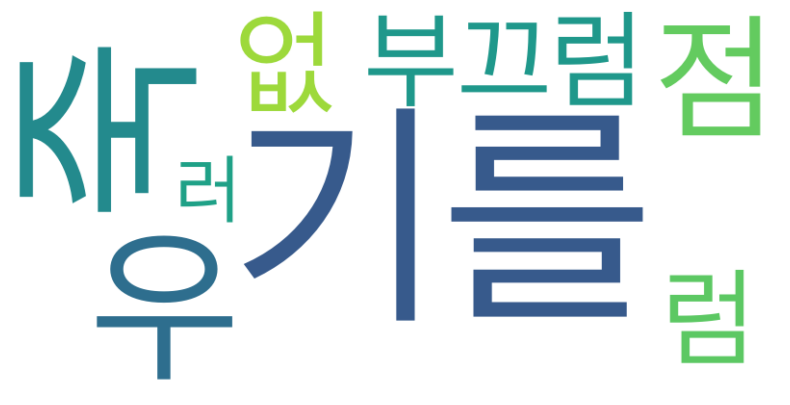

In [39]:
wc = WordCloud(
    font_path="/System/Library/Fonts/AppleSDGothicNeo.ttc",  # macOS
    background_color="white",
    width=800,
    height=400
)

wc.generate_from_frequencies(token_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()
